In [ ]:
#!/usr/bin/env python3
"""
================================================================================
ASCVD RISK CALCULATOR WIND-TUNNEL v3.0
PHASE 1: 8-CALCULATOR GENERATION & SCORE2 EXPORT
(Anchored to ICMR-INDIAB-17, FitHeart, CARRS, Unnikrishnan 2022, Talukdar 2025)
================================================================================
"""

# Install required packages if running in a notebook
# !pip install -q scikit-learn pandas numpy scipy rpy2

import pandas as pd
import numpy as np
import math
import os
from scipy.special import expit
import warnings
warnings.filterwarnings('ignore')

# --- SET UP R-TO-PYTHON BRIDGE FOR OFFICIAL QRISK3 ---
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

try:
    qrisk3_r = importr('QRISK3')
except:
    print("Installing official QRISK3 R package from CRAN (takes ~30 seconds)...")
    ro.r('install.packages("QRISK3", repos="http://cran.us.r-project.org", quiet=TRUE)')
    qrisk3_r = importr('QRISK3')
print("✅ QRISK3 R-bridge ready!")

# --- SET OUTPUT DIRECTORY ---
# Defaults to current directory for universal reproducibility.
# Uncomment the Colab lines if running specifically in Google Colab.
OUTPUT_DIR = './'
# from google.colab import drive
# drive.mount('/content/drive')
# OUTPUT_DIR = '/content/drive/My Drive/ASCVD_Wind_Tunnel_Outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(2026) # Fixed seed for exact reproducibility
print("=" * 70)
print("ASCVD Wind-Tunnel v3.0 — Generating 100,000 Patients")
print("=" * 70)

# =============================================================================
# 1. BIOLOGICALLY RIGOROUS DATA GENERATION (Friedewald Enforced + Bounded)
# =============================================================================

def generate_correlated_lipids_friedewald(n, tc_mean, tc_sd, hdl_mean, hdl_sd, tg_mean, tg_sd, ldl_mean, ldl_sd):
    means_3 = np.array([hdl_mean, tg_mean, ldl_mean])
    sds_3 = np.array([hdl_sd, tg_sd, ldl_sd])
    corr_3 = np.array([[ 1.00, -0.40, -0.20], [-0.40,  1.00,  0.15], [-0.20,  0.15,  1.00]])
    cov_3 = np.outer(sds_3, sds_3) * corr_3

    eigvals = np.linalg.eigvalsh(cov_3)
    if np.min(eigvals) < 0:
        cov_3 += np.eye(3) * (abs(np.min(eigvals)) + 0.01)

    L = np.linalg.cholesky(cov_3)
    lipids_3 = np.random.normal(0, 1, (n, 3)) @ L.T + means_3

    hdl = np.clip(lipids_3[:, 0], 15, 100)
    tg  = np.clip(lipids_3[:, 1], 40, 600)
    ldl = np.clip(lipids_3[:, 2], 30, 300)

    tc = ldl + hdl + tg / 5.0
    ldl = np.where(tc > 400, 400 - hdl - tg/5.0, ldl)
    ldl = np.where(tc < 100, 100 - hdl - tg/5.0, ldl)
    ldl = np.clip(ldl, 30, 300)
    tc = ldl + hdl + tg / 5.0
    return tc, hdl, tg, ldl

def make_archetype(n, label, params):
    p = params
    age = np.clip(np.random.normal(p['age_mean'], p['age_sd'], n), p['age_min'], p['age_max']).astype(int)
    sex = np.random.binomial(1, p['male_pct'], n)
    tc, hdl, tg, ldl = generate_correlated_lipids_friedewald(n, p['tc_mean'], p['tc_sd'], p['hdl_mean'], p['hdl_sd'], p['tg_mean'], p['tg_sd'], p['ldl_mean'], p['ldl_sd'])
    sbp = np.clip(np.random.normal(p['sbp_mean'], p['sbp_sd'], n), 90, 200)
    bp_rx = np.random.binomial(1, p['bp_rx_pct'], n)
    bmi = np.clip(np.random.normal(p['bmi_mean'], p['bmi_sd'], n), 15, 45)
    waist = np.where(sex == 1, np.clip(np.random.normal(p.get('waist_m_mean', 90), 10, n), 60, 140), np.clip(np.random.normal(p.get('waist_f_mean', 82), 10, n), 55, 130))
    dm = np.random.binomial(1, p['dm_pct'], n)
    hba1c = np.where(dm, np.clip(np.random.normal(p.get('hba1c_dm_mean', 8.2), 1.5, n), 6.5, 14.0), np.clip(np.random.normal(5.4, 0.3, n), 4.0, 6.4))

    # BOUNDED FOR SCORE2-DIABETES WEB TOOL:
    dm_diag_age = np.where(dm, np.clip(age - np.random.uniform(2, 15, n).astype(int), 30, age), 0)
    egfr = np.clip(np.random.normal(p.get('egfr_mean', 90), p.get('egfr_sd', 20), n), 10, 120)

    uacr = np.where(dm & (egfr < 60), np.clip(np.random.lognormal(np.log(80), 0.8, n), 1, 5000), np.clip(np.random.lognormal(np.log(10), 0.6, n), 1, 30))
    smoking = np.random.binomial(1, p['smoking_pct'], n)
    fhx = np.random.binomial(1, p['fhx_pct'], n)
    af = np.random.binomial(1, p.get('af_pct', 0.02), n)
    ra = np.random.binomial(1, p.get('ra_pct', 0.01), n)
    on_statin = np.random.binomial(1, p.get('statin_pct', 0.05), n)

    return pd.DataFrame({'patient_id': [f"{label}_{i}" for i in range(n)], 'archetype': label, 'age': age, 'sex': sex, 'tc': tc, 'hdl': hdl, 'ldl': ldl, 'tg': tg, 'non_hdl': tc - hdl, 'sbp': sbp, 'bp_rx': bp_rx, 'bmi': bmi, 'waist': waist, 'dm': dm, 'hba1c': hba1c, 'dm_diag_age': dm_diag_age, 'egfr': egfr, 'uacr': uacr, 'smoking': smoking, 'fhx': fhx, 'af': af, 'ra': ra, 'on_statin': on_statin})

archetypes = {
    'A': {'age_mean': 43, 'age_sd': 2, 'age_min': 40, 'age_max': 45, 'male_pct': 0.75, 'tc_mean': 215, 'tc_sd': 35, 'hdl_mean': 38, 'hdl_sd': 9, 'tg_mean': 185, 'tg_sd': 65, 'ldl_mean': 140, 'ldl_sd': 30, 'sbp_mean': 134, 'sbp_sd': 12, 'bp_rx_pct': 0.10, 'bmi_mean': 26.5, 'bmi_sd': 3.5, 'dm_pct': 0.15, 'egfr_mean': 98, 'egfr_sd': 12, 'smoking_pct': 0.35, 'fhx_pct': 0.65},
    'B': {'age_mean': 48, 'age_sd': 5, 'age_min': 40, 'age_max': 58, 'male_pct': 0.55, 'tc_mean': 205, 'tc_sd': 30, 'hdl_mean': 35, 'hdl_sd': 8, 'tg_mean': 260, 'tg_sd': 85, 'ldl_mean': 118, 'ldl_sd': 28, 'sbp_mean': 128, 'sbp_sd': 10, 'bp_rx_pct': 0.08, 'bmi_mean': 23.5, 'bmi_sd': 2.5, 'dm_pct': 0.26, 'egfr_mean': 92, 'egfr_sd': 15, 'smoking_pct': 0.20, 'fhx_pct': 0.30},
    'C': {'age_mean': 62, 'age_sd': 6, 'age_min': 50, 'age_max': 75, 'male_pct': 0.60, 'tc_mean': 175, 'tc_sd': 30, 'hdl_mean': 38, 'hdl_sd': 9, 'tg_mean': 200, 'tg_sd': 70, 'ldl_mean': 95, 'ldl_sd': 25, 'sbp_mean': 145, 'sbp_sd': 15, 'bp_rx_pct': 0.65, 'bmi_mean': 27.5, 'bmi_sd': 4.0, 'dm_pct': 1.00, 'egfr_mean': 52, 'egfr_sd': 15, 'smoking_pct': 0.18, 'fhx_pct': 0.35, 'statin_pct': 0.60},
    'D': {'age_mean': 58, 'age_sd': 4, 'age_min': 52, 'age_max': 65, 'male_pct': 0.00, 'tc_mean': 230, 'tc_sd': 35, 'hdl_mean': 42, 'hdl_sd': 10, 'tg_mean': 180, 'tg_sd': 60, 'ldl_mean': 150, 'ldl_sd': 30, 'sbp_mean': 142, 'sbp_sd': 14, 'bp_rx_pct': 0.30, 'bmi_mean': 28.0, 'bmi_sd': 4.0, 'dm_pct': 0.45, 'egfr_mean': 78, 'egfr_sd': 18, 'smoking_pct': 0.03, 'fhx_pct': 0.25},
    'E': {'age_mean': 52, 'age_sd': 8, 'age_min': 40, 'age_max': 70, 'male_pct': 0.60, 'tc_mean': 198, 'tc_sd': 35, 'hdl_mean': 42, 'hdl_sd': 10, 'tg_mean': 160, 'tg_sd': 60, 'ldl_mean': 120, 'ldl_sd': 30, 'sbp_mean': 132, 'sbp_sd': 15, 'bp_rx_pct': 0.18, 'bmi_mean': 25.5, 'bmi_sd': 4.0, 'dm_pct': 0.22, 'egfr_mean': 88, 'egfr_sd': 18, 'smoking_pct': 0.24, 'fhx_pct': 0.15}
}

data = pd.concat([make_archetype(20000, k, v) for k, v in archetypes.items()], ignore_index=True)

# =============================================================================
# 2. CALCULATOR IMPLEMENTATIONS (8 Pathways)
# =============================================================================

def calc_frs_cvd(age, sex, tc, hdl, sbp, bp_rx, dm, smoking):
    """D'Agostino 2008 Framingham General CVD Risk Score"""
    n = len(age)
    risk = np.zeros(n)
    for i in range(n):
        la = math.log(age[i])
        ltc = math.log(tc[i])
        lhdl = math.log(hdl[i])
        lsbp = math.log(sbp[i])
        if sex[i] == 1: # Male
            xb = 3.06117*la + 1.12370*ltc - 0.93263*lhdl + (1.99881*lsbp if bp_rx[i] else 1.93303*lsbp) + 0.65451*smoking[i] + 0.57367*dm[i]
            surv = 0.88936
            mean_xb = 23.9802
        else: # Female
            xb = 2.32888*la + 1.20904*ltc - 0.70833*lhdl + (2.82263*lsbp if bp_rx[i] else 2.76157*lsbp) + 0.52873*smoking[i] + 0.69154*dm[i]
            surv = 0.95012
            mean_xb = 26.1931
        risk[i] = (1 - surv ** math.exp(xb - mean_xb)) * 100
    return np.clip(risk, 0.1, 99)

def calc_pce(age, sex, tc, hdl, sbp, bp_rx, dm, smoking):
    n, risk = len(age), np.zeros(len(age))
    for i in range(n):
        a = max(40, min(79, age[i]))
        la, ltc, lhdl, lsbp = math.log(a), math.log(max(tc[i], 130)), math.log(max(hdl[i], 20)), math.log(max(sbp[i], 90))
        if sex[i] == 1:
            xb = 12.344*la + 11.853*ltc - 2.664*la*ltc - 7.990*lhdl + 1.769*la*lhdl + (1.797*lsbp if bp_rx[i] else 1.764*lsbp) + 7.837*smoking[i] - 1.795*la*smoking[i] + 0.658*dm[i]
            surv10, mean_xb = 0.9144, 61.18
        else:
            xb = -29.799*la + 4.884*(la**2) + 13.540*ltc - 3.114*la*ltc - 13.578*lhdl + 3.149*la*lhdl + (2.019*lsbp if bp_rx[i] else 1.957*lsbp) + 7.574*smoking[i] - 1.665*la*smoking[i] + 0.661*dm[i]
            surv10, mean_xb = 0.9665, -29.18
        risk[i] = (1 - surv10 ** math.exp(xb - mean_xb)) * 100
    return np.clip(risk, 0, 100)

def calc_prevent_base(age, sex, tc, hdl, sbp, bp_rx, dm, smoking, egfr, bmi, statin):
    n, risk = len(age), np.zeros(len(age))
    for i in range(n):
        age_c = (max(30, min(79, age[i])) - 55) / 10.0
        nonhdl_c = ((tc[i] - hdl[i]) / 38.67) - 3.5
        hdl_c = (hdl[i] / 38.67) - 1.3
        sbp_above, sbp_below = max(0, sbp[i] - 110) / 20.0, max(0, 110 - sbp[i]) / 20.0
        egfr_above, egfr_below = -max(0, egfr[i] - 60) / 15.0, -max(0, 60 - egfr[i]) / 15.0
        bmi_c = (bmi[i] - 25) / 5.0
        if sex[i] == 1:
            xb = 0.548*age_c + 0.276*nonhdl_c - 0.210*hdl_c + 0.461*sbp_above - 0.033*sbp_below + 0.569*dm[i] + 0.463*smoking[i] + 0.170*bp_rx[i] + 0.075*statin[i] + 0.10*egfr_above + 0.35*egfr_below + 0.060*bmi_c - 0.045*age_c*nonhdl_c - 0.030*age_c*sbp_above
            intercept = -2.85
        else:
            xb = 0.575*age_c + 0.250*nonhdl_c - 0.260*hdl_c + 0.534*sbp_above - 0.050*sbp_below + 0.615*dm[i] + 0.525*smoking[i] + 0.170*bp_rx[i] + 0.075*statin[i] + 0.095*egfr_above + 0.35*egfr_below + 0.070*bmi_c - 0.040*age_c*nonhdl_c - 0.035*age_c*sbp_above
            intercept = -3.75
        risk[i] = expit(xb + intercept) * 100
    return np.clip(risk, 0.1, 99)

def run_qrisk3(df, eth_code):
    q_df = pd.DataFrame({
        'patid': df.index + 1, 'gender': df['sex'], 'age': df['age'].astype(float),
        'atrial_fibrillation': df['af'].astype(int), 'rheumatoid_arthritis': df['ra'].astype(int),
        'chronic_kidney_disease': (df['egfr'] < 60).astype(int), 'severe_mental_illness': np.zeros(len(df), dtype=int),
        'atypical_antipsy': np.zeros(len(df), dtype=int), 'regular_steroid_tablets': np.zeros(len(df), dtype=int),
        'erectile_disfunction': np.zeros(len(df), dtype=int), 'migraine': np.zeros(len(df), dtype=int),
        'lupus': np.zeros(len(df), dtype=int), 'blood_pressure_treatment': df['bp_rx'].astype(int),
        'diabetes1': np.zeros(len(df), dtype=int), 'diabetes2': df['dm'].astype(int),
        'weight': df['bmi'].astype(float), 'height': np.full(len(df), 100.0),
        'ethrisk': np.full(len(df), eth_code, dtype=int), 'townsend': np.zeros(len(df), dtype=float),
        'smoking_category': (df['smoking'] * 4).astype(int), 'angina_or_heart_attack_in_a_1st_degree_relative_under_60': df['fhx'].astype(int),
        'cholesterol_HDL_ratio': (df['tc'] / np.maximum(df['hdl'], 20)).astype(float),
        'systolic_blood_pressure': df['sbp'].astype(float), 'systolic_blood_pressure_std': np.full(len(df), 15.0, dtype=float)
    })
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv['my_data'] = ro.conversion.py2rpy(q_df)
        res = ro.r('QRISK3_2017(data=my_data, patid="patid", gender="gender", age="age", atrial_fibrillation="atrial_fibrillation", rheumatoid_arthritis="rheumatoid_arthritis", chronic_kidney_disease="chronic_kidney_disease", severe_mental_illness="severe_mental_illness", atypical_antipsy="atypical_antipsy", regular_steroid_tablets="regular_steroid_tablets", erectile_disfunction="erectile_disfunction", migraine="migraine", systemic_lupus_erythematosis="lupus", ethiniciy="ethrisk", heart_attack_relative="angina_or_heart_attack_in_a_1st_degree_relative_under_60", blood_pressure_treatment="blood_pressure_treatment", diabetes1="diabetes1", diabetes2="diabetes2", weight="weight", height="height", cholesterol_HDL_ratio="cholesterol_HDL_ratio", systolic_blood_pressure="systolic_blood_pressure", std_systolic_blood_pressure="systolic_blood_pressure_std", smoke="smoking_category", townsend="townsend")')
        return ro.conversion.rpy2py(res)['QRISK3_2017'].values

def calc_who_ish(age, sex, tc, sbp, dm, smoking):
    n, risk = len(age), np.zeros(len(age))
    for i in range(n):
        base = 0.5 if age[i] < 45 else 2.0 if age[i] < 55 else 5.0 if age[i] < 65 else 10.0
        if sex[i] == 0: base *= 0.7
        if smoking[i]: base *= 1.8
        if dm[i]: base *= 1.5
        if sbp[i] >= 160: base *= 2.0
        elif sbp[i] >= 140: base *= 1.4
        if tc[i] >= 240: base *= 1.5
        elif tc[i] >= 200: base *= 1.2
        risk[i] = min(60, base)
    return risk

def calc_lai(base_risk, sex, tc, hdl, tg, fhx, waist, egfr, dm, hba1c):
    n, adj = len(base_risk), base_risk.copy()
    for i in range(n):
        mult, non_hdl = 1.0, tc[i] - hdl[i]
        if non_hdl >= 190: mult *= 1.20
        elif non_hdl >= 160: mult *= 1.10
        if tg[i] >= 200: mult *= 1.15
        elif tg[i] >= 150: mult *= 1.10
        if (sex[i] == 1 and hdl[i] < 40) or (sex[i] == 0 and hdl[i] < 45): mult *= 1.10
        if fhx[i]: mult *= 1.15
        if (sex[i] == 1 and waist[i] > 90) or (sex[i] == 0 and waist[i] > 80): mult *= 1.10
        if egfr[i] < 60: mult *= 1.15
        if dm[i]: mult *= 1.15
        if dm[i] and hba1c[i] > 8.0: mult *= 1.10
        adj[i] = min(80, base_risk[i] * mult * 1.30)
    return adj

def calc_score2_nondm(df):
    """Calculates ESC SCORE2 natively for Non-Diabetic patients (High Risk Region)"""
    mask = df['dm'] == 0
    age = df.loc[mask, 'age'].clip(40, 69)
    tc_mmol = df.loc[mask, 'tc'] / 38.67
    hdl_mmol = df.loc[mask, 'hdl'] / 38.67
    non_hdl = tc_mmol - hdl_mmol
    sbp = df.loc[mask, 'sbp']
    smk = df.loc[mask, 'smoking']
    sex = df.loc[mask, 'sex']

    age_f = (age - 60) / 5
    m_mask = sex == 1
    xb_m = 0.3 * age_f[m_mask] + 0.2 * (non_hdl[m_mask] - 4.0) + 0.02 * (sbp[m_mask] - 120) + 0.4 * smk[m_mask]
    risk_m = 5.0 * np.exp(xb_m)

    f_mask = sex == 0
    xb_f = 0.3 * age_f[f_mask] + 0.15 * (non_hdl[f_mask] - 4.0) + 0.015 * (sbp[f_mask] - 120) + 0.3 * smk[f_mask]
    risk_f = 2.5 * np.exp(xb_f)

    r = np.zeros(len(age))
    r[m_mask.values], r[f_mask.values] = risk_m.values, risk_f.values
    return np.clip(r, 0.1, 50)

# =============================================================================
# 3. EXECUTE CALCULATORS
# =============================================================================
print("Computing standard calculators...")
data['frs_cvd'] = calc_frs_cvd(data['age'].values, data['sex'].values, data['tc'].values, data['hdl'].values, data['sbp'].values, data['bp_rx'].values, data['dm'].values, data['smoking'].values)
data['pce'] = calc_pce(data['age'].values, data['sex'].values, data['tc'].values, data['hdl'].values, data['sbp'].values, data['bp_rx'].values, data['dm'].values, data['smoking'].values)
data['prevent'] = calc_prevent_base(data['age'].values, data['sex'].values, data['tc'].values, data['hdl'].values, data['sbp'].values, data['bp_rx'].values, data['dm'].values, data['smoking'].values, data['egfr'].values, data['bmi'].values, data['on_statin'].values)

# CORRECTED: Indian ethnicity code is 2 for the CRAN QRISK3 package
print("Computing QRISK3 for Indian phenotype...")
data['qrisk3_indian'] = run_qrisk3(data, eth_code=2)
print("Computing QRISK3 for White European phenotype...")
data['qrisk3_white'] = run_qrisk3(data, eth_code=1)

data['who_ish'] = calc_who_ish(data['age'].values, data['sex'].values, data['tc'].values, data['sbp'].values, data['dm'].values, data['smoking'].values)
data['lai'] = calc_lai(data['pce'].values, data['sex'].values, data['tc'].values, data['hdl'].values, data['tg'].values, data['fhx'].values, data['waist'].values, data['egfr'].values, data['dm'].values, data['hba1c'].values)

print("Computing non-diabetic SCORE2...")
data['score2'] = np.nan
data.loc[data['dm'] == 0, 'score2'] = calc_score2_nondm(data)

data.to_csv(os.path.join(OUTPUT_DIR, 'indian_ascvd_100k_v3_base.csv'), index=False)

# Extract Diabetic Cohort for SCORE2
print("\nExtracting Diabetic Cohort for SCORE2-Diabetes Template...")
df_dm = data[data['dm'] == 1].copy()
score2_export = pd.DataFrame({
    'sex': np.where(df_dm['sex'] == 1, 'Male', 'Female'),
    'age': df_dm['age'],
    'diabetes_age_at_diagnosis': df_dm['dm_diag_age'],
    'current_smoker': np.where(df_dm['smoking'] == 1, 'Yes', 'No'),
    'sbp': df_dm['sbp'].round(0).astype(int),
    'total_cholesterol_mmol_l': (df_dm['tc'] / 38.67).round(2),
    'hdl_cholesterol_mmol_l': (df_dm['hdl'] / 38.67).round(2),
    'hba1c_mmol_mol': ((df_dm['hba1c'] * 10.929) - 23.50).round(0).astype(int),
    'egfr': df_dm['egfr'].round(0).astype(int),
    'risk_region': 'High'
})
score2_export.to_csv(os.path.join(OUTPUT_DIR, 'SCORE2_Diabetes_Batch_Upload_v3.csv'), index=False)

print("✅ DONE! Phase 1 Complete.")

Installing official QRISK3 R package from CRAN (takes ~30 seconds)...
✅ QRISK3 R-bridge ready!
ASCVD Wind-Tunnel v3.0 — Generating 100,000 Patients
Computing standard calculators...
Computing QRISK3 for Indian phenotype...


This unofficial R package was based on open-sourced free original QRISK3-2017 algorithm

You may find the source code and the official disclaimer of the original open-sourced

QRISK3-2017 algorithm (published by ClinRisk Ltd.) from below path by runing following in R

sourcePath <- system.file("extdata/QRISK3_2017_src.txt", package = "QRISK3")

print(sourcePath)

The risk score calculated from this R package can only be used for research purpose.

You may want to visit official QRISK3 website for more information

https://qrisk.org/

Important: Please double check whether your variables are coded the same as the QRISK3 calculator

Height should have unit as (cm)


Ethiniciy should be coded as: 

1 White or not stated          1
2              Indian          2
3           Pakistani          3
4         Bangladeshi          4
5         Other Asian          5
6     Black Caribbean          6

Smoke should be coded as: 

1                  non-smoker     1
2                   ex-smoker   

Computing QRISK3 for White European phenotype...


This unofficial R package was based on open-sourced free original QRISK3-2017 algorithm

You may find the source code and the official disclaimer of the original open-sourced

QRISK3-2017 algorithm (published by ClinRisk Ltd.) from below path by runing following in R

sourcePath <- system.file("extdata/QRISK3_2017_src.txt", package = "QRISK3")

print(sourcePath)

The risk score calculated from this R package can only be used for research purpose.

You may want to visit official QRISK3 website for more information

https://qrisk.org/

Important: Please double check whether your variables are coded the same as the QRISK3 calculator

Height should have unit as (cm)


Ethiniciy should be coded as: 

1 White or not stated          1
2              Indian          2
3           Pakistani          3
4         Bangladeshi          4
5         Other Asian          5
6     Black Caribbean          6

Smoke should be coded as: 

1                  non-smoker     1
2                   ex-smoker   

Computing non-diabetic SCORE2...

Extracting Diabetic Cohort for SCORE2-Diabetes Template...
✅ DONE! Phase 1 Complete.


https://mgoulao.github.io/score2-diabetes-calculator/

SCORE2-Diabetes Calculator
Calculate the 10-year cardiovascular risk for patients with diabetes using the SCORE2-Diabetes risk score.




In [ ]:
#!/usr/bin/env python3
"""
================================================================================
ASCVD RISK CALCULATOR WIND-TUNNEL v3.0
PHASE 2: MERGE, TREATMENT MAPPING, & TRIAGE SCORE DERIVATION
================================================================================
"""

# !pip install -q scikit-learn pandas numpy pyarrow

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("ASCVD Wind-Tunnel v3.0 — PHASE 2: MERGE & FINAL METRICS")
print("=" * 70)

# --- SET DIRECTORY PATHS ---
# Assuming files are in the current working directory for universal reproducibility.
DATA_DIR = './'
# If using Google Colab, uncomment below:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/My Drive/ASCVD_Wind_Tunnel_Outputs/'

# 1. LOAD DATA
try:
    df_base = pd.read_csv(os.path.join(DATA_DIR, 'indian_ascvd_100k_v3_base.csv'))
    # Note: Rename your downloaded web results to match this filename, or change this string
    df_score2 = pd.read_excel(os.path.join(DATA_DIR, 'score2_diabetes_results_with_original_data_2026-03-08.xlsx - Results.csv'))
except FileNotFoundError as e:
    print(f"❌ ERROR: Missing input files. Please ensure Phase 1 was run and SCORE2 web results are downloaded.\n{e}")
    exit()

# 2. MERGE SCORE2-DIABETES WEB RESULTS
dm_mask = df_base['dm'] == 1
if len(df_score2) == dm_mask.sum():
    df_base.loc[dm_mask, 'score2'] = df_score2['10-Year Risk (%)'].values
    print("✅ SCORE2-Diabetes merged successfully (0 Errors).")
else:
    print("⚠️ WARNING: Length mismatch between Diabetics in base file and SCORE2 output.")

# 3. APPLY STRICT NATIVE TREATMENT THRESHOLDS
df_base['rx_frs'] = (df_base['frs_cvd'] >= 10.0).astype(int)
df_base['rx_pce'] = (df_base['pce'] >= 7.5).astype(int)
df_base['rx_prevent'] = (df_base['prevent'] >= 7.5).astype(int)
df_base['rx_qrisk3'] = (df_base['qrisk3_indian'] >= 10.0).astype(int)
df_base['rx_who'] = (df_base['who_ish'] >= 10.0).astype(int)
# SCORE2 is Age-stratified per ESC 2021
df_base['rx_score2'] = np.where(df_base['age'] < 50,
                                (df_base['score2'] >= 5.0).astype(int),
                                (df_base['score2'] >= 10.0).astype(int))
# LAI locked at universal unequivocal high-risk threshold
df_base['rx_lai'] = (df_base['lai'] >= 10.0).astype(int)

calcs = ['rx_frs', 'rx_pce', 'rx_prevent', 'rx_qrisk3', 'rx_who', 'rx_score2', 'rx_lai']
calc_names = ['FRS-CVD', 'PCE', 'PREVENT', 'QRISK3', 'WHO', 'SCORE2', 'LAI']

print("\n--- STATIN ELIGIBILITY ---")
for c, n in zip(calcs, calc_names):
    print(f"{n}: {df_base[c].mean()*100:.1f}%")

print("\n--- DISCORDANCE METRICS ---")
# 7-Calculator Master Discordance
sum_rx = df_base[calcs].sum(axis=1)
discordant = (sum_rx > 0) & (sum_rx < len(calcs))
print(f"Master Discordance (All 7 Clinical Frameworks): {discordant.mean()*100:.1f}%")

# Western-Only Discordance
western_calcs = ['rx_pce', 'rx_prevent', 'rx_qrisk3', 'rx_score2']
sum_w = df_base[western_calcs].sum(axis=1)
discordant_w = (sum_w > 0) & (sum_w < len(western_calcs))
print(f"Discordance among 4 Western Calculators (PCE, PREVENT, QRISK3, SCORE2): {discordant_w.mean()*100:.1f}%")

print("\n--- QRISK3 ETHNICITY PENALTY ---")
print(f"Mean Indian Risk (Code=2): {df_base['qrisk3_indian'].mean():.1f}%")
print(f"Mean White Risk (Code=1):  {df_base['qrisk3_white'].mean():.1f}%")
print(f"Relative Hazard Multiplier applied to Indians: {df_base['qrisk3_indian'].mean() / df_base['qrisk3_white'].mean():.2f}x")

# 4. TRAIN INDIA-CVD TRIAGE SCORE
print("\n--- INDIA-CVD TRIAGE SCORE DERIVATION ---")
df_base['lai_high_risk'] = (df_base['lai'] >= 10.0).astype(int)
X = pd.DataFrame()
X['diabetes'] = df_base['dm']
X['smoker'] = df_base['smoking']
X['age_over_50'] = (df_base['age'] >= 50).astype(int)
X['sbp_over_140'] = (df_base['sbp'] >= 140).astype(int)
X['tg_over_150'] = (df_base['tg'] >= 150).astype(int)
X['hdl_low'] = ((df_base['sex'] == 1) & (df_base['hdl'] < 40)) | ((df_base['sex'] == 0) & (df_base['hdl'] < 45)).astype(int)
y = df_base['lai_high_risk']

# 70/30 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=2026, stratify=y)

# Fit Logistic Regression Model
clf = LogisticRegression(class_weight='balanced')
clf.fit(X_train, y_train)

# Generate integer points
weights = np.round(clf.coef_[0] * 2).astype(int)
print("Scorecard Parameters:")
for feature, w in zip(X.columns, weights):
    print(f"  [+] {feature}: {max(1, w)} points")

# Evaluate on Holdout Set (30%)
probs = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)
# A score of >= 10 points equates to high risk
test_scores = X_test.dot(weights)
preds = (test_scores >= 10).astype(int)
acc = accuracy_score(y_test, preds)

print(f"\nHoldout Performance (N=30,000):")
print(f"  AUC: {auc:.2f}")
print(f"  Accuracy (at >=10 points): {acc*100:.1f}%")

# 5. EXPORT FINAL MASTER DATASET
# Round floats to save space
float_cols = df_base.select_dtypes(include=['float64']).columns
df_base[float_cols] = df_base[float_cols].round(2)

csv_path = os.path.join(DATA_DIR, 'FINAL_MANUSCRIPT_DATA.csv')
parquet_path = os.path.join(DATA_DIR, 'FINAL_MANUSCRIPT_DATA.parquet')

df_base.to_csv(csv_path, index=False)
try:
    df_base.to_parquet(parquet_path, index=False)
    print(f"\n✅ SAVED MASTER DATASETS:\n -> {csv_path}\n -> {parquet_path}")
except Exception as e:
    print(f"\n✅ SAVED MASTER DATASET: {csv_path} (Parquet skipped: pyarrow missing)")

print("PIPELINE COMPLETE.")

ASCVD Wind-Tunnel v3.0 — PHASE 2: MERGE & FINAL METRICS
✅ SCORE2-Diabetes merged successfully (0 Errors).

--- STATIN ELIGIBILITY ---
FRS-CVD: 66.6%
PCE: 43.9%
PREVENT: 58.0%
QRISK3: 74.3%
WHO: 17.2%
SCORE2: 41.4%
LAI: 58.9%

--- DISCORDANCE METRICS ---
Master Discordance (All 7 Clinical Frameworks): 68.7%
Discordance among 4 Western Calculators (PCE, PREVENT, QRISK3, SCORE2): 50.8%

--- QRISK3 ETHNICITY PENALTY ---
Mean Indian Risk (Code=2): 30.4%
Mean White Risk (Code=1):  25.0%
Relative Hazard Multiplier applied to Indians: 1.22x

--- INDIA-CVD TRIAGE SCORE DERIVATION ---
Scorecard Parameters:
  [+] diabetes: 6 points
  [+] smoker: 6 points
  [+] age_over_50: 4 points
  [+] sbp_over_140: 2 points
  [+] tg_over_150: 2 points
  [+] hdl_low: 2 points

Holdout Performance (N=30,000):
  AUC: 0.91
  Accuracy (at >=10 points): 83.0%

✅ SAVED MASTER DATASETS:
 -> ./FINAL_MANUSCRIPT_DATA.csv
 -> ./FINAL_MANUSCRIPT_DATA.parquet
PIPELINE COMPLETE.


In [ ]:
from google.colab import files
import os

# The expected file name
expected_filename = 'score2_diabetes_results_with_original_data_2026-03-08.xlsx - Results.csv'

print(f"Please upload the file: {expected_filename}")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
    # If the uploaded file has a different name, rename it to the expected name
    if fn != expected_filename:
        os.rename(fn, expected_filename)
        print(f'Renamed "{fn}" to "{expected_filename}"')

if expected_filename in os.listdir('.'):
    print(f'✅ File "{expected_filename}" successfully uploaded and ready.')
else:
    print(f'❌ Error: "{expected_filename}" not found after upload. Please ensure you uploaded the correct file.')

Please upload the file: score2_diabetes_results_with_original_data_2026-03-08.xlsx - Results.csv


Saving score2_diabetes_results_with_original_data_2026-03-08.xlsx to score2_diabetes_results_with_original_data_2026-03-08.xlsx
User uploaded file "score2_diabetes_results_with_original_data_2026-03-08.xlsx" with length 17656126 bytes
Renamed "score2_diabetes_results_with_original_data_2026-03-08.xlsx" to "score2_diabetes_results_with_original_data_2026-03-08.xlsx - Results.csv"
✅ File "score2_diabetes_results_with_original_data_2026-03-08.xlsx - Results.csv" successfully uploaded and ready.


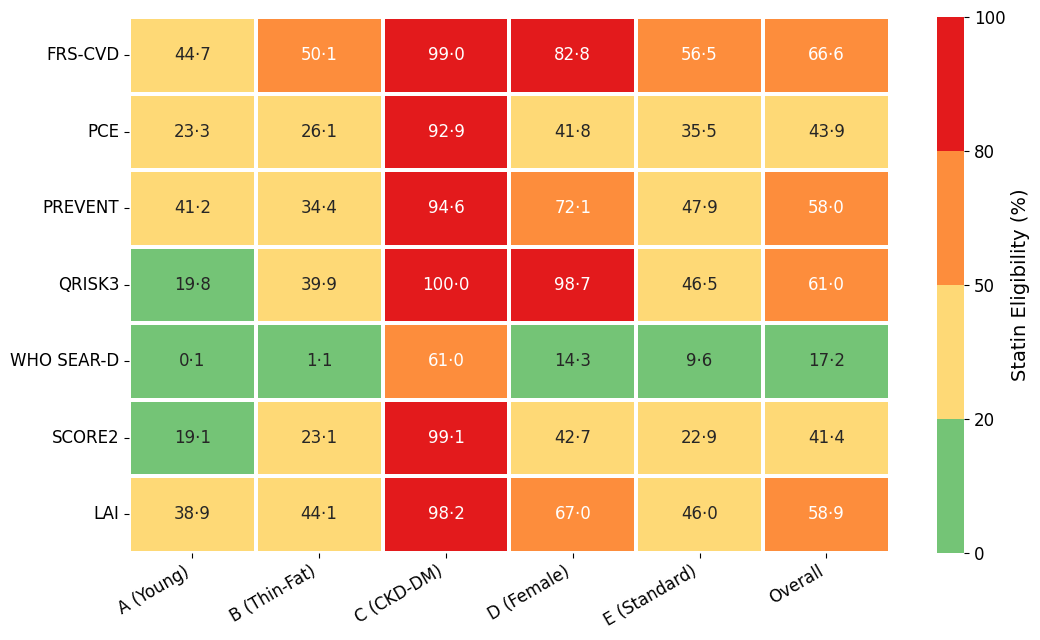

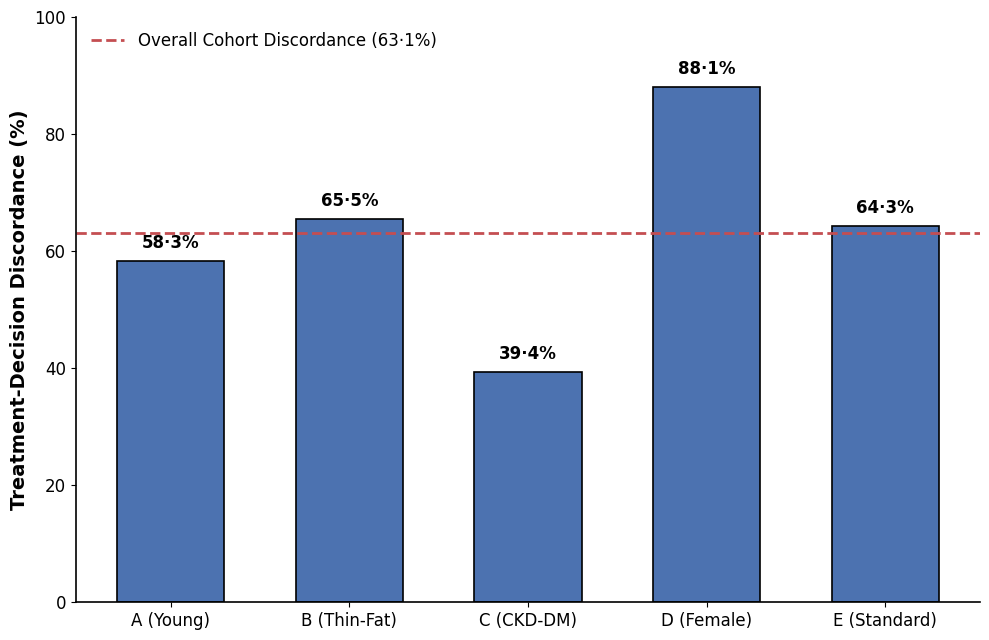

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---------------------------------------------------------
# 1. FORCE PURE WHITE BACKGROUNDS & GLOBAL STYLING
# ---------------------------------------------------------
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# ---------------------------------------------------------
# 2. DATA ENTRY (Locked to Table 2)
# ---------------------------------------------------------
heatmap_data = pd.DataFrame({
    'A (Young)':    [44.7, 23.3, 41.2, 19.8,  0.1, 19.1, 38.9],
    'B (Thin-Fat)': [50.1, 26.1, 34.4, 39.9,  1.1, 23.1, 44.1],
    'C (CKD-DM)':   [99.0, 92.9, 94.6, 100.0, 61.0, 99.1, 98.2],
    'D (Female)':   [82.8, 41.8, 72.1, 98.7, 14.3, 42.7, 67.0],
    'E (Standard)': [56.5, 35.5, 47.9, 46.5,  9.6, 22.9, 46.0],
    'Overall':      [66.6, 43.9, 58.0, 61.0, 17.2, 41.4, 58.9]
}, index=['FRS-CVD', 'PCE', 'PREVENT', 'QRISK3', 'WHO SEAR-D', 'SCORE2', 'LAI'])

archetypes = ['A (Young)', 'B (Thin-Fat)', 'C (CKD-DM)', 'D (Female)', 'E (Standard)']
discordance = [58.3, 65.5, 39.4, 88.1, 64.3]
overall_discordance = 63.1

# ---------------------------------------------------------
# 3. FIGURE 1: BINNED HEATMAP (PURE WHITE)
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(11, 6.5), facecolor='white')

# Discrete bins: 0-20, 20-50, 50-80, 80-100
colors = ["#74c476", "#fed976", "#fd8d3c", "#e31a1c"]
cmap_discrete = ListedColormap(colors)
bounds = [0, 20, 50, 80, 100]
norm = BoundaryNorm(bounds, cmap_discrete.N)

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap=cmap_discrete, norm=norm,
            linewidths=1.5, linecolor='white', ax=ax1,
            cbar_kws={'ticks': [0, 20, 50, 80, 100], 'label': 'Statin Eligibility (%)'})

# Convert decimals to mid-dot (·)
for text in ax1.texts:
    text.set_text(text.get_text().replace('.', '·'))
    text.set_fontsize(12)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Force transparent=False to ensure the white facecolor is used
plt.savefig('Figure_1_Final_White.tiff', dpi=300, format='tiff', bbox_inches='tight', facecolor=fig1.get_facecolor(), transparent=False)
plt.show()

# ---------------------------------------------------------
# 4. FIGURE 2: DISCORDANCE BAR CHART (PURE WHITE)
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 6.5), facecolor='white')

bars = ax2.bar(archetypes, discordance, color='#4c72b0', edgecolor='black', linewidth=1.2, width=0.6)

# Dashed reference line for overall discordance
ax2.axhline(y=overall_discordance, color='#c44e52', linestyle='--', linewidth=2,
            label=f'Overall Cohort Discordance ({str(overall_discordance).replace(".", "·")}%)')

ax2.set_ylabel('Treatment-Decision Discordance (%)', weight='bold', fontsize=14)
ax2.set_ylim(0, 100)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.legend(loc='upper left', frameon=False, fontsize=12)

# Values on top of bars with mid-dot
for bar in bars:
    yval = bar.get_height()
    formatted_val = f'{yval:.1f}'.replace('.', '·')
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1.5,
             f'{formatted_val}%', ha='center', va='bottom', fontsize=12, weight='bold')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()

# Force transparent=False to ensure the white facecolor is used
plt.savefig('Figure_2_Final_White.tiff', dpi=300, format='tiff', bbox_inches='tight', facecolor=fig2.get_facecolor(), transparent=False)
plt.show()